## Load User Data

In [1]:
import pandas as pd
import numpy as np
import json

BANNED_USERS = {51, 86, 62, 39, 66, 89, 67, 57} # failed attention checks

with open('../llm_judge/results/judge_submission/gemini/gemini-3.1-pro-preview.jsonl', 'r') as json_file:
    json_list = list(json_file)


user_to_rubric = dict()
for json_str in json_list:
    result = json.loads(json_str)
    if result['user_id'] in BANNED_USERS:
        continue
    key = (result['user_id'], result['task'])
    arr = user_to_rubric.get(key, [])
    arr.append(int(result['prediction']))
    user_to_rubric[key] = arr

with open('../data/user_code.json') as json_data:
    d = json.load(json_data)
    new_d = []
    for row in d:
        if row['user_id'] in BANNED_USERS:
            continue
        row['initial_code_accuracy'] = np.mean(user_to_rubric[(row['user_id'], 'initial_code')])
        row['extension_code_accuracy'] = np.mean(user_to_rubric[(row['user_id'], 'extension_code')])
        new_d.append(row)

df = pd.DataFrame(new_d)
df['background_ability'] = [float(x) for x in df['background_ability']]

/fs/clip-quiz/nbalepur/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/fs/clip-quiz/nbalepur/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Statistical Tests

Logic for Figure 1

In [2]:
# !pip install pingouin
# Install pingouin if needed

In [3]:
import pingouin as pg
import numpy as np

agent_vals = []
chatbot_vals = []
p_vals = []
d_vals = []

t_test_columns = ['initial_code_accuracy', 'authorship_and_comprehension', 'extension_code_accuracy']
for col in t_test_columns:
    curr_agent_vals = list(df[df['experiment_group'] == 'agent'][col])
    curr_chatbot_vals = list(df[df['experiment_group'] == 'chat'][col])
    
    _, _, _, p_val, _, cohen_d, _, _ = pg.ttest(curr_agent_vals, curr_chatbot_vals, correction=True).iloc[0]
    
    print('Metric:', col)
    print('p-value:', p_val)
    print("Cohen's D:", cohen_d)
    print('----------------')
    
    agent_vals.append(np.mean(curr_agent_vals))
    chatbot_vals.append(np.mean(curr_chatbot_vals))
    p_vals.append(p_val)
    d_vals.append(cohen_d)
  
df_subset = df[df['initial_code_accuracy'] > 0.5]

curr_agent_vals = list(df_subset[df_subset['experiment_group'] == 'agent']['extension_code_accuracy'])
curr_chatbot_vals = list(df_subset[df_subset['experiment_group'] == 'chat']['extension_code_accuracy'])

_, _, _, p_val, _, cohen_d, _, _ = pg.ttest(curr_agent_vals, curr_chatbot_vals, correction=True).iloc[0]

print('Metric:', 'extension_code_accuracy (initial_code_accuracy > 0.5)')
print('p-value:', p_val)
print("Cohen's D:", cohen_d)
print('----------------')

agent_vals.append(np.mean(curr_agent_vals))
chatbot_vals.append(np.mean(curr_chatbot_vals))
p_vals.append(p_val)
d_vals.append(cohen_d)

Metric: initial_code_accuracy
p-value: 1.9339733977453118e-05
Cohen's D: 1.39501560203747
----------------
Metric: authorship_and_comprehension
p-value: 0.0012171588190514916
Cohen's D: 0.931855862287502
----------------
Metric: extension_code_accuracy
p-value: 0.4450748448299704
Cohen's D: 0.20944780939822044
----------------
Metric: extension_code_accuracy (initial_code_accuracy > 0.5)
p-value: 0.17574562705788502
Cohen's D: 0.45011543498283496
----------------


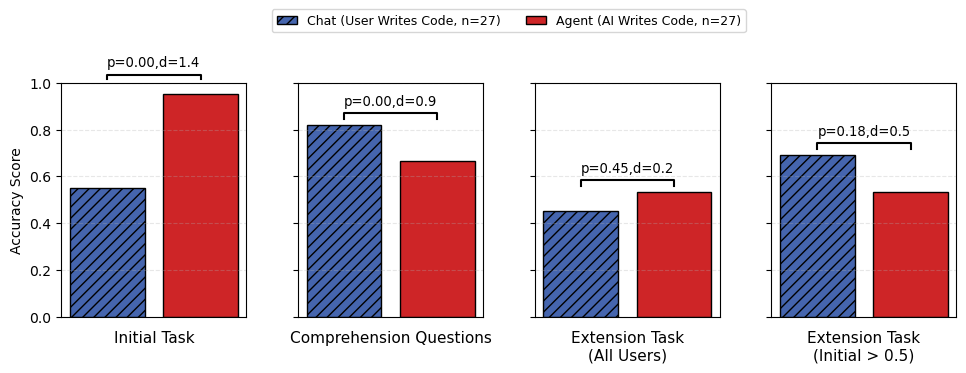

In [4]:
"""Plot Generated by Cursor"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

col_names = ['Initial Task', 'Comprehension Questions', 'Extension Task\n(All Users)', 'Extension Task\n(Initial > 0.5)']
num_chat = 27
num_agent = 27

group_colors = {"agent": "#ce2527", "chat": "#4565ae"}
x = np.arange(2)
x_no_ai, x_ai = 0.0, 1.0

fig, axes = plt.subplots(1, len(col_names), figsize=(10, 4), sharey=False)

for idx, ax in enumerate(axes):
    values = np.array([chatbot_vals[idx], agent_vals[idx]], dtype=float)
    colors = [group_colors["chat"], group_colors["agent"]]
    bars = ax.bar(
        x,
        values,
        color=colors,
        edgecolor="black",
        linewidth=1.0,
    )
    bars[0].set_hatch("///")

    y_min, y_max = 0.0, 1.0
    y_span = y_max - y_min
    y_pad = y_span * 0.06

    if np.all(np.isfinite(values)):
        top_clearance = y_max - float(np.nanmax(values))
        if idx == 0:
            bracket_y = 1.015
            bracket_h = 0.02
            text_y = 1.055
        elif top_clearance < 0.08:
            bracket_y = y_max - 0.16
            bracket_h = 0.025
            text_y = bracket_y + bracket_h + 0.012
        else:
            bracket_y = min(float(np.nanmax(values)) + y_pad * 0.4, y_max - y_pad * 2.2)
            bracket_h = y_pad * 0.45
            text_y = bracket_y + bracket_h + y_pad * 0.3

        ax.plot(
            [x_ai, x_ai, x_no_ai, x_no_ai],
            [bracket_y, bracket_y + bracket_h, bracket_y + bracket_h, bracket_y],
            color="black",
            linewidth=1.5,
            clip_on=False,
            zorder=6,
        )
        p_val = p_vals[idx]
        cohen_val = d_vals[idx]
        p_text = (
            f"p={p_val:.2f},d={cohen_val:.1f}"
            if np.isfinite(p_val)
            else "p = n/a"
        )
        ax.text(
            (x_ai + x_no_ai) / 2,
            text_y,
            p_text,
            ha="center",
            va="bottom",
            color="black",
            zorder=5,
            clip_on=False,
            fontsize=9.5,
        )
        if idx != 0:
            text_y = min(text_y, y_max - 0.045)

    ax.set_ylim(y_min, y_max)
    ax.set_xticks([])
    ax.set_xticklabels([])
    ax.set_xlabel(col_names[idx], labelpad=10, fontsize=11)
    ax.set_title("")
    if idx == 0:
        ax.set_ylabel("Accuracy Score")
    else:
        ax.tick_params(axis="y", labelleft=False)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

SUB_LEFT, SUB_BOTTOM, SUB_RIGHT, SUB_TOP = 0.09, 0.155, 0.985, 0.74
plt.subplots_adjust(
    left=SUB_LEFT, right=SUB_RIGHT, bottom=SUB_BOTTOM, top=SUB_TOP, wspace=0.28
)
legend_center_x = (SUB_LEFT + SUB_RIGHT) / 2
LEGEND_GAP_ABOVE_AXES = 0.11
legend_anchor_y = SUB_TOP + LEGEND_GAP_ABOVE_AXES
legend_handles = [
    Patch(
        facecolor=group_colors["chat"],
        edgecolor="black",
        hatch="///",
        label=f"Chat (User Writes Code, n={num_chat})",
    ),
    Patch(
        facecolor=group_colors["agent"],
        edgecolor="black",
        label=f"Agent (AI Writes Code, n={num_agent})",
    ),
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=2,
    frameon=True,
    bbox_to_anchor=(legend_center_x, legend_anchor_y),
    bbox_transform=fig.transFigure,
    fontsize=9,
    handlelength=1.6,
)
plt.show()

In [5]:
# Comparing just authorship and just comprehension questions
t_test_columns = ['authorship', 'comprehension']
for col in t_test_columns:
    curr_agent_vals = list(df[df['experiment_group'] == 'agent'][col])
    curr_chatbot_vals = list(df[df['experiment_group'] == 'chat'][col])
    
    _, _, _, p_val, _, cohen_d, _, _ = pg.ttest(curr_agent_vals, curr_chatbot_vals, correction=True).iloc[0]
    
    print('Metric:', col)
    print('p-value:', p_val)
    print("Cohen's D:", cohen_d)
    print('----------------')

Metric: authorship
p-value: 2.8783876168105904e-05
Cohen's D: 1.2508171321960766
----------------
Metric: comprehension
p-value: 0.07749633054302535
Cohen's D: 0.49908530486101654
----------------


## Boxplot

Distribution of all user scores (Figure 4)

In [6]:
agent_vals = []
chatbot_vals = []

t_test_columns = [['background_ability'], ['initial_code_accuracy', 'extension_code_accuracy'], ['initial_time_to_submit_seconds', 'extension_time_to_submit_seconds'], ['authorship', 'comprehension']]

for col_list in t_test_columns:
    curr_agent_vals = []
    curr_chatbot_vals = []
    for col in col_list:            
        a = list(df[df['experiment_group'] == 'agent'][col])
        c = list(df[df['experiment_group'] == 'chat'][col])
        curr_agent_vals.append([float(a_) for a_ in a])
        curr_chatbot_vals.append([float(c_) for c_ in c])
    agent_vals.append(curr_agent_vals)
    chatbot_vals.append(curr_chatbot_vals)

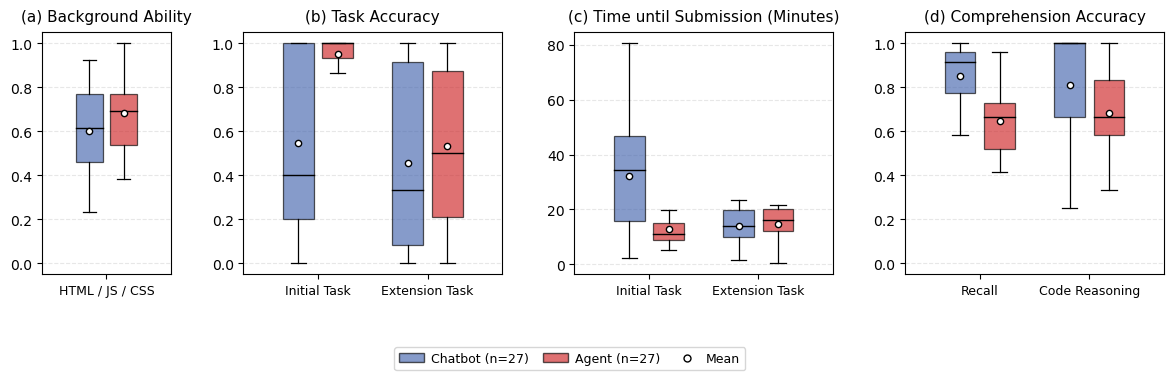

In [7]:
"""Plot Generated by Cursor"""

from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import pandas as pd

GROUP_ORDER = ["chat", "agent"]
GROUP_COLORS = {"agent": "#ce2527", "chat": "#4565ae"}
GROUP_LABELS = {"agent": "Agent", "chat": "Chatbot"}


def _clean_1d(vals: list[float] | np.ndarray) -> np.ndarray:
    a = np.asarray(vals, dtype=float)
    return a[~np.isnan(a)]


def add_box_panel_from_lists(
    ax: plt.Axes,
    chat_vals_per_metric: list[list[float]],
    agent_vals_per_metric: list[list[float]],
    metric_labels: list[str],
    panel_title: str,
) -> None:
    """Same layout/styling as add_box_panel in box_plot.py (chat left, agent right)."""
    centers = np.arange(len(metric_labels), dtype=float)
    offset = 0.18
    box_width = 0.28

    for group_idx, group_name in enumerate(GROUP_ORDER):
        direction = -1 if group_idx == 0 else 1
        positions = centers + direction * offset
        raw = chat_vals_per_metric if group_name == "chat" else agent_vals_per_metric
        values_by_metric = [_clean_1d(v) for v in raw]

        boxplot = ax.boxplot(
            values_by_metric,
            positions=positions,
            widths=box_width,
            patch_artist=True,
            showmeans=True,
            meanline=False,
            showfliers=False,
        )
        for patch in boxplot["boxes"]:
            patch.set_facecolor(GROUP_COLORS[group_name])
            patch.set_edgecolor("black")
            patch.set_alpha(0.65)
            patch.set_linewidth(0.9)
        for whisker in boxplot["whiskers"]:
            whisker.set_color("black")
            whisker.set_linewidth(0.9)
        for cap in boxplot["caps"]:
            cap.set_color("black")
            cap.set_linewidth(0.9)
        for median in boxplot["medians"]:
            median.set_color("black")
            median.set_linewidth(1.0)
        for mean in boxplot["means"]:
            mean.set_marker("o")
            mean.set_markerfacecolor("white")
            mean.set_markeredgecolor("black")
            mean.set_markersize(4.5)
            mean.set_linestyle("none")

    ax.set_xticks(centers)
    ax.set_xticklabels(metric_labels, fontsize=9)
    ax.set_title(panel_title, fontsize=11, pad=8)
    ax.grid(axis="y", linestyle="--", alpha=0.3)


def seconds_to_minutes(vals: list[float]) -> list[float]:
    return [float(v) / 60.0 for v in vals]


def plot_box_figure_from_vals(
    agent_vals: list[list[list[float]]],
    chatbot_vals: list[list[list[float]]],
    out_path: Path | str | None = None,
) -> plt.Figure:
    """
    agent_vals / chatbot_vals: outer index = panel, middle = metric within panel,
    inner = per-participant values.
    """
    if len(agent_vals) != len(chatbot_vals):
        raise ValueError("agent_vals and chatbot_vals must have the same number of panels")

    # Panel (c) in box_plot.py uses minutes
    chat_panels = []
    agent_panels = []
    for panel_idx, (a_panel, c_panel) in enumerate(zip(agent_vals, chatbot_vals, strict=True)):
        if panel_idx == 2:
            agent_panels.append([seconds_to_minutes(col) for col in a_panel])
            chat_panels.append([seconds_to_minutes(col) for col in c_panel])
        else:
            agent_panels.append([list(col) for col in a_panel])
            chat_panels.append([list(col) for col in c_panel])

    metric_labels_per_panel = [
        ["HTML / JS / CSS"],
        ["Initial Task", "Extension Task"],
        ["Initial Task", "Extension Task"],
        ["Recall", "Code Reasoning"],
    ]
    titles = [
        "(a) Background Ability",
        "(b) Task Accuracy",
        "(c) Time until Submission (Minutes)",
        "(d) Comprehension Accuracy",
    ]

    fig, axes = plt.subplots(1, 4, figsize=(12, 4), sharey=False, gridspec_kw={"width_ratios": [1, 2, 2, 2]})

    n_agent = len(agent_panels[0][0]) if agent_panels[0] else 0
    n_chat = len(chat_panels[0][0]) if chat_panels[0] else 0

    for i, ax in enumerate(axes):
        add_box_panel_from_lists(
            ax,
            chat_vals_per_metric=chat_panels[i],
            agent_vals_per_metric=agent_panels[i],
            metric_labels=metric_labels_per_panel[i],
            panel_title=titles[i],
        )
        if i in (0, 1, 3):
            ax.set_ylim(-0.05, 1.05)

    legend_handles: list[Patch | Line2D] = []
    for group_name in GROUP_ORDER:
        n_group = n_chat if group_name == "chat" else n_agent
        group_label = GROUP_LABELS.get(group_name, group_name.title())
        legend_handles.append(
            Patch(
                facecolor=GROUP_COLORS.get(group_name, "#888888"),
                edgecolor="black",
                alpha=0.65,
                label=f"{group_label} (n={n_group})",
            )
        )
    legend_handles.append(
        Line2D(
            [0],
            [0],
            marker="o",
            markersize=5,
            markerfacecolor="white",
            markeredgecolor="black",
            color="black",
            linestyle="None",
            label="Mean",
        )
    )

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=max(2, len(legend_handles)),
        frameon=True,
        bbox_to_anchor=(0.5, 0.02),
        fontsize=9,
        handletextpad=0.5,
        columnspacing=1.2,
    )
    plt.subplots_adjust(left=0.06, right=0.995, bottom=0.275, top=0.88, wspace=0.32)


agent_vals: list[list[list[float]]] = []
chatbot_vals: list[list[list[float]]] = []
for col_list in t_test_columns:
    curr_agent_vals: list[list[float]] = []
    curr_chatbot_vals: list[list[float]] = []
    for col in col_list:
        a = list(df[df["experiment_group"] == "agent"][col])
        c = list(df[df["experiment_group"] == "chat"][col])
        curr_agent_vals.append([float(a_) for a_ in a])
        curr_chatbot_vals.append([float(c_) for c_ in c])
    agent_vals.append(curr_agent_vals)
    chatbot_vals.append(curr_chatbot_vals)

plot_box_figure_from_vals(
    agent_vals,
    chatbot_vals
)

In [8]:
# Verify values match up w/ boxplot

print('Name', 'Agent', 'Chatbot')

import numpy as np
for col_idx in range(len(t_test_columns)):
    for idx in range(len(t_test_columns[col_idx])):
        print(t_test_columns[col_idx][idx], np.mean(agent_vals[col_idx][idx]), np.mean([x for x in chatbot_vals[col_idx][idx] if str(x) != 'nan']))

Name Agent Chatbot
background_ability 0.680911680911681 0.6011396011396012
initial_code_accuracy 0.9506172839506173 0.5481481481481482
extension_code_accuracy 0.5339506172839507 0.4537037037037037
initial_time_to_submit_seconds 782.1938408518517 1921.1697787037035
extension_time_to_submit_seconds 884.5651212222224 833.474296037037
authorship 0.646604938271605 0.8495370370370371
comprehension 0.685185185185185 0.8106666666666666


## Self-Reported Feedback

Table 3

In [34]:
import pandas as pd

with open('../data/numeric_ratings.jsonl', 'r') as json_file:
    json_list = list(json_file)
    
with open('../data/user_code.json') as json_data:
    d = json.load(json_data)
    user_to_group = {row['user_id']: row['experiment_group'] for row in d}

feedback_df = pd.DataFrame([json.loads(row) for row in json_list])
feedback_df['group'] = [user_to_group[user_id] for user_id in feedback_df['user_id']]
feedback_df = feedback_df[feedback_df['project_id'] == 'initial']

In [35]:
feedback_df.groupby(['question', 'group'])['score'].agg(
    lambda x: f"{x.mean():.2f} ± {x.std(ddof=1)/np.sqrt(x.count()):.2f}"
).unstack()

group,agent,chat
question,,
"For future tasks, I would prefer Agent Mode: A model that can directly access and edit your code",4.16 ± 0.20,3.92 ± 0.22
"For future tasks, I would prefer Chat Mode: A model that can only provide syntax help without access to your code",3.16 ± 0.27,2.71 ± 0.24
"For future tasks, I would prefer No AI Assistance",1.44 ± 0.19,1.88 ± 0.24
"For future tasks, I would prefer The option to switch between Chat Mode and Agent Mode",4.60 ± 0.20,4.08 ± 0.25
"I could easily add new features (e.g., new game rules, UI components, CSS styles) to my code without using AI tools.",3.07 ± 0.26,3.15 ± 0.24
I read and reviewed the AI chatbot's responses.,NaN,3.96 ± 0.16
I read and reviewed the AI-generated code.,3.22 ± 0.27,NaN
I understand how my code works.,3.33 ± 0.25,4.15 ± 0.15
The AI in Agent Mode (where it directly edited files) was helpful for this task.,4.70 ± 0.17,NaN


## Regressions

### Analysis of Background Ability (Figure 5)

In [9]:
import statsmodels.formula.api as smf
import pandas as pd

outcomes = [
    "initial_code_accuracy",
    "authorship_and_comprehension",
    "extension_code_accuracy"
]

rows = []

for outcome in outcomes:
    formula = f"{outcome} ~ background_ability * experiment_group"
    res = smf.ols(formula, data=df).fit()

    params = res.params
    ci = res.conf_int()
    ci.columns = ["ci_low", "ci_high"]
    
    # Group CI
    is_chatbot = params["experiment_group[T.chat]"]
    is_chatbot_ci = ci.loc["experiment_group[T.chat]"]
    
    # BG ability of agent => when interaction is 0
    bg_agent = params["background_ability"]
    bg_agent_ci = ci.loc["background_ability"]

    # BG ability of chatbot => need a separate t-test 
    bg_chatbot_test = res.t_test(
        "background_ability + background_ability:experiment_group[T.chat] = 0"
    )
    bg_chatbot = params["background_ability"] + params["background_ability:experiment_group[T.chat]"]
    bg_chatbot_ci_low, bg_chatbot_ci_high = bg_chatbot_test.conf_int()[0]

    rows.append({
        "outcome": outcome,
        "adj_r2": res.rsquared_adj,

        "is_chatbot": is_chatbot,
        "is_chatbot_ci_low": is_chatbot_ci["ci_low"],
        "is_chatbot_ci_high": is_chatbot_ci["ci_high"],

        "bg_agent": bg_agent,
        "bg_agent_ci_low": bg_agent_ci["ci_low"],
        "bg_agent_ci_high": bg_agent_ci["ci_high"],

        "bg_chatbot": bg_chatbot,
        "bg_chatbot_ci_low": bg_chatbot_ci_low,
        "bg_chatbot_ci_high": bg_chatbot_ci_high,
    })

coeff_df = pd.DataFrame(rows)
coeff_df.T

,0,1,2
outcome,initial_code_accuracy,authorship_and_comprehension,extension_code_accuracy
adj_r2,0.36758,0.398243,0.045448
is_chatbot,-0.889484,0.292911,-0.436517
is_chatbot_ci_low,-1.446898,0.010944,-1.18199
is_chatbot_ci_high,-0.33207,0.574879,0.308956
bg_agent,-0.094598,0.561987,0.227459
bg_agent_ci_low,-0.678599,0.266571,-0.55357
bg_agent_ci_high,0.489403,0.857403,1.008488
bg_chatbot,0.703002,0.40634,0.8503
bg_chatbot_ci_low,0.104714,0.103697,0.050165


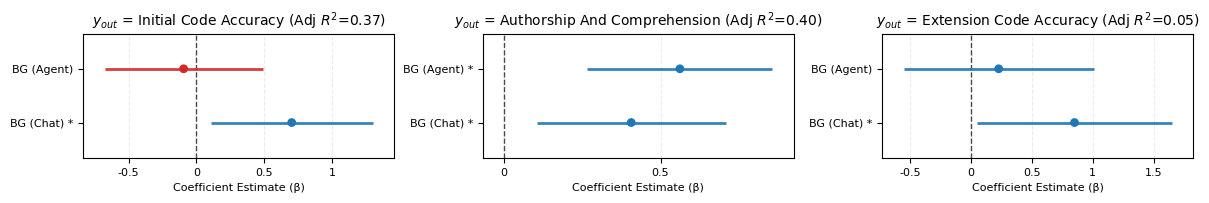

In [10]:
"""Cursor-Generated Plot"""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter, MultipleLocator

n_outcomes = len(coeff_df)
fig, axes = plt.subplots(1, n_outcomes, figsize=(4 * n_outcomes, 2))
axes = np.atleast_1d(axes)

row_spacing = 0.84
row_pad = 0.55
row_labels = ("BG (Agent)", "BG (Chat)")
x_fmt = FuncFormatter(lambda v, _: str(int(round(v))) if np.isclose(v, round(v)) else f"{v:g}")

for ax, (_, row) in zip(axes, coeff_df.iterrows()):
    coef = np.array([row["bg_agent"], row["bg_chatbot"]], dtype=float)
    ci_lo = np.array([row["bg_agent_ci_low"], row["bg_chatbot_ci_low"]], dtype=float)
    ci_hi = np.array([row["bg_agent_ci_high"], row["bg_chatbot_ci_high"]], dtype=float)
    y = np.arange(len(row_labels), dtype=float) * row_spacing

    colors = np.where(coef >= 0, "#1f77b4", "#d62728")
    ax.axvline(0, color="k", linestyle="--", linewidth=1, alpha=0.7)
    ax.hlines(y, ci_lo, ci_hi, colors=colors, linewidth=2, alpha=0.9)
    ax.scatter(coef, y, c=colors, s=28, zorder=3)

    x_span = max(np.ptp(np.r_[ci_lo, ci_hi, 0.0]), 0.15)
    pad = 0.08 * x_span
    ax.set_xlim(min(ci_lo.min(), 0.0) - pad, max(ci_hi.max(), 0.0) + pad)
    ax.set_ylim(y[-1] + row_pad, y[0] - row_pad)
    ax.set_yticks(y)

    y_tick_labels = []
    for label, lo, hi in zip(row_labels, ci_lo, ci_hi):
        significant = (lo > 0 and hi > 0) or (lo < 0 and hi < 0)
        y_tick_labels.append(f"{label} *" if significant else label)
    ax.set_yticklabels(y_tick_labels, fontsize=8)

    ax.grid(axis="x", linestyle="--", alpha=0.25)
    ax.xaxis.set_major_locator(MultipleLocator(0.5))
    ax.xaxis.set_major_formatter(x_fmt)
    ax.tick_params(axis="x", labelsize=8)

    outcome_title = str(row["outcome"]).replace("_", " ").title()
    adj_r2 = float(row["adj_r2"])
    ax.set_title(rf"$y_{{out}}$ = {outcome_title} (Adj $R^2$={adj_r2:.2f})", fontsize=10)
    ax.set_xlabel("Coefficient Estimate (β)", fontsize=8)

fig.tight_layout(pad=0.6)
plt.show()

### Mediation Analysis: Predicting Comprehension (Figure 6)

In [11]:
import statsmodels.formula.api as smf
import pandas as pd

formula = f"authorship_and_comprehension ~ background_ability * experiment_group + initial_code_accuracy"
res = smf.ols(formula, data=df).fit()

params = res.params
ci = res.conf_int()
ci.columns = ["ci_low", "ci_high"]

# Group CI
is_chatbot = params["experiment_group[T.chat]"]
is_chatbot_ci = ci.loc["experiment_group[T.chat]"]

# BG ability of agent => when interaction is 0
bg_agent = params["background_ability"]
bg_agent_ci = ci.loc["background_ability"]

# BG ability of chatbot => need a separate t-test 
bg_chatbot_test = res.t_test(
    "background_ability + background_ability:experiment_group[T.chat] = 0"
)
bg_chatbot = params["background_ability"] + params["background_ability:experiment_group[T.chat]"]
bg_chatbot_ci_low, bg_chatbot_ci_high = bg_chatbot_test.conf_int()[0]

# Impact of initial task accuracy
initial_task = params["initial_code_accuracy"]
initial_task_ci = ci.loc["initial_code_accuracy"]

rows = [{
    "outcome": "authorship_and_comprehension",
    "adj_r2": res.rsquared_adj,

    "is_chatbot": is_chatbot,
    "is_chatbot_ci_low": is_chatbot_ci["ci_low"],
    "is_chatbot_ci_high": is_chatbot_ci["ci_high"],

    "bg_agent": bg_agent,
    "bg_agent_ci_low": bg_agent_ci["ci_low"],
    "bg_agent_ci_high": bg_agent_ci["ci_high"],

    "bg_chatbot": bg_chatbot,
    "bg_chatbot_ci_low": bg_chatbot_ci_low,
    "bg_chatbot_ci_high": bg_chatbot_ci_high,
    
    "initial_task": initial_task,
    "initial_task_ci_low": initial_task_ci["ci_low"],
    "initial_task_ci_high": initial_task_ci["ci_high"],
}]

mediation_1_df = pd.DataFrame(rows)
mediation_1_df.T

,0
outcome,authorship_and_comprehension
adj_r2,0.420199
is_chatbot,0.399156
is_chatbot_ci_low,0.095121
is_chatbot_ci_high,0.703191
bg_agent,0.573286
bg_agent_ci_low,0.282856
bg_agent_ci_high,0.863716
bg_chatbot,0.32237
bg_chatbot_ci_low,0.009031


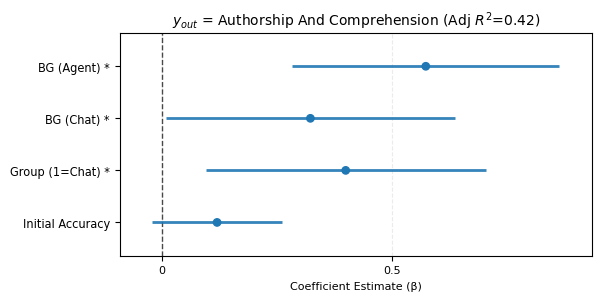

In [12]:
"""Cursor-Generated Plot"""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter, MultipleLocator

row = mediation_1_df.iloc[0]

plot_rows = [
    ("BG (Agent)", float(row["bg_agent"]), float(row["bg_agent_ci_low"]), float(row["bg_agent_ci_high"])),
    ("BG (Chat)", float(row["bg_chatbot"]), float(row["bg_chatbot_ci_low"]), float(row["bg_chatbot_ci_high"])),
    ("Group (1=Chat)", float(row["is_chatbot"]), float(row["is_chatbot_ci_low"]), float(row["is_chatbot_ci_high"])),
    ("Initial Accuracy", float(row["initial_task"]), float(row["initial_task_ci_low"]), float(row["initial_task_ci_high"])),
]

row_labels = [r[0] for r in plot_rows]
coef = np.array([r[1] for r in plot_rows], dtype=float)
ci_lo = np.array([r[2] for r in plot_rows], dtype=float)
ci_hi = np.array([r[3] for r in plot_rows], dtype=float)

row_spacing = 0.86
row_pad = 0.55
y = np.arange(len(plot_rows), dtype=float) * row_spacing

colors = np.where(coef >= 0, "#1f77b4", "#d62728")
x_fmt = FuncFormatter(lambda v, _: str(int(round(v))) if np.isclose(v, round(v)) else f"{v:g}")

fig, ax = plt.subplots(1, 1, figsize=(6, 3))
ax.axvline(0, color="k", linestyle="--", linewidth=1, alpha=0.7)
ax.hlines(y, ci_lo, ci_hi, colors=colors, linewidth=2, alpha=0.9)
ax.scatter(coef, y, c=colors, s=28, zorder=3)

x_span = max(np.ptp(np.r_[ci_lo, ci_hi, 0.0]), 0.15)
pad = 0.08 * x_span
ax.set_xlim(min(ci_lo.min(), 0.0) - pad, max(ci_hi.max(), 0.0) + pad)
ax.set_ylim(y[-1] + row_pad, y[0] - row_pad)
ax.set_yticks(y)

y_tick_labels = []
for label, lo, hi in zip(row_labels, ci_lo, ci_hi):
    significant = (lo > 0 and hi > 0) or (lo < 0 and hi < 0)
    y_tick_labels.append(f"{label} *" if significant else label)
ax.set_yticklabels(y_tick_labels, fontsize=8.2)

ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.xaxis.set_major_locator(MultipleLocator(0.5))
ax.xaxis.set_major_formatter(x_fmt)
ax.tick_params(axis="x", labelsize=8)

outcome_title = str(row["outcome"]).replace("_", " ").title()
adj_r2 = float(row["adj_r2"])
ax.set_title(rf"$y_{{out}}$ = {outcome_title} (Adj $R^2$={adj_r2:.2f})", fontsize=10)
ax.set_xlabel("Coefficient Estimate (β)", fontsize=8)

fig.tight_layout(pad=0.65)
plt.show()

### Mediation Analysis: Predicting Extension Accuracy (Figure 7)

In [13]:
import statsmodels.formula.api as smf
import pandas as pd

formula = f"extension_code_accuracy ~ background_ability * experiment_group + initial_code_accuracy + authorship_and_comprehension"
res = smf.ols(formula, data=df).fit()

params = res.params
ci = res.conf_int()
ci.columns = ["ci_low", "ci_high"]

# Group CI
is_chatbot = params["experiment_group[T.chat]"]
is_chatbot_ci = ci.loc["experiment_group[T.chat]"]

# BG ability of agent => when interaction is 0
bg_agent = params["background_ability"]
bg_agent_ci = ci.loc["background_ability"]

# BG ability of chatbot => need a separate t-test 
bg_chatbot_test = res.t_test(
    "background_ability + background_ability:experiment_group[T.chat] = 0"
)
bg_chatbot = params["background_ability"] + params["background_ability:experiment_group[T.chat]"]
bg_chatbot_ci_low, bg_chatbot_ci_high = bg_chatbot_test.conf_int()[0]

# Impact of initial task accuracy
initial_task = params["initial_code_accuracy"]
initial_task_ci = ci.loc["initial_code_accuracy"]

# Impact of comprehension
comprehension = params["authorship_and_comprehension"]
comprehension_ci = ci.loc["authorship_and_comprehension"]

rows = [{
    "outcome": "authorship_and_comprehension",
    "adj_r2": res.rsquared_adj,

    "is_chatbot": is_chatbot,
    "is_chatbot_ci_low": is_chatbot_ci["ci_low"],
    "is_chatbot_ci_high": is_chatbot_ci["ci_high"],

    "bg_agent": bg_agent,
    "bg_agent_ci_low": bg_agent_ci["ci_low"],
    "bg_agent_ci_high": bg_agent_ci["ci_high"],

    "bg_chatbot": bg_chatbot,
    "bg_chatbot_ci_low": bg_chatbot_ci_low,
    "bg_chatbot_ci_high": bg_chatbot_ci_high,
    
    "initial_task": initial_task,
    "initial_task_ci_low": initial_task_ci["ci_low"],
    "initial_task_ci_high": initial_task_ci["ci_high"],
    
    "comprehension": comprehension,
    "comprehension_ci_low": comprehension_ci["ci_low"],
    "comprehension_ci_high": comprehension_ci["ci_high"],
}]

mediation_2_df = pd.DataFrame(rows)
mediation_2_df.T

,0
outcome,authorship_and_comprehension
adj_r2,0.342055
is_chatbot,-0.38431
is_chatbot_ci_low,-1.111243
is_chatbot_ci_high,0.342623
bg_agent,-0.354856
bg_agent_ci_low,-1.10172
bg_agent_ci_high,0.392008
bg_chatbot,0.102669
bg_chatbot_ci_low,-0.628309


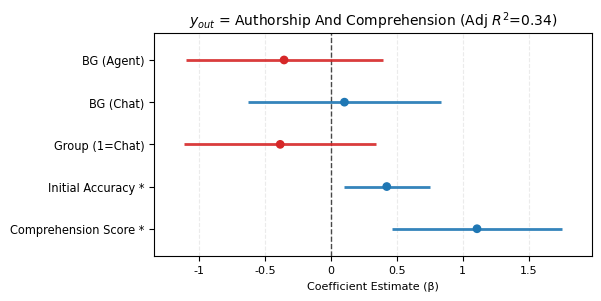

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter, MultipleLocator

row = mediation_2_df.iloc[0]

plot_rows = [
    ("BG (Agent)", float(row["bg_agent"]), float(row["bg_agent_ci_low"]), float(row["bg_agent_ci_high"])),
    ("BG (Chat)", float(row["bg_chatbot"]), float(row["bg_chatbot_ci_low"]), float(row["bg_chatbot_ci_high"])),
    ("Group (1=Chat)", float(row["is_chatbot"]), float(row["is_chatbot_ci_low"]), float(row["is_chatbot_ci_high"])),
    ("Initial Accuracy", float(row["initial_task"]), float(row["initial_task_ci_low"]), float(row["initial_task_ci_high"])),
    ("Comprehension Score", float(row["comprehension"]), float(row["comprehension_ci_low"]), float(row["comprehension_ci_high"])),
]

row_labels = [r[0] for r in plot_rows]
coef = np.array([r[1] for r in plot_rows], dtype=float)
ci_lo = np.array([r[2] for r in plot_rows], dtype=float)
ci_hi = np.array([r[3] for r in plot_rows], dtype=float)

row_spacing = 0.86
row_pad = 0.55
y = np.arange(len(plot_rows), dtype=float) * row_spacing

colors = np.where(coef >= 0, "#1f77b4", "#d62728")
x_fmt = FuncFormatter(lambda v, _: str(int(round(v))) if np.isclose(v, round(v)) else f"{v:g}")

fig, ax = plt.subplots(1, 1, figsize=(6, 3))
ax.axvline(0, color="k", linestyle="--", linewidth=1, alpha=0.7)
ax.hlines(y, ci_lo, ci_hi, colors=colors, linewidth=2, alpha=0.9)
ax.scatter(coef, y, c=colors, s=28, zorder=3)

x_span = max(np.ptp(np.r_[ci_lo, ci_hi, 0.0]), 0.15)
pad = 0.08 * x_span
ax.set_xlim(min(ci_lo.min(), 0.0) - pad, max(ci_hi.max(), 0.0) + pad)
ax.set_ylim(y[-1] + row_pad, y[0] - row_pad)
ax.set_yticks(y)

y_tick_labels = []
for label, lo, hi in zip(row_labels, ci_lo, ci_hi):
    significant = (lo > 0 and hi > 0) or (lo < 0 and hi < 0)
    y_tick_labels.append(f"{label} *" if significant else label)
ax.set_yticklabels(y_tick_labels, fontsize=8.2)

ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.xaxis.set_major_locator(MultipleLocator(0.5))
ax.xaxis.set_major_formatter(x_fmt)
ax.tick_params(axis="x", labelsize=8)

outcome_title = str(row["outcome"]).replace("_", " ").title()
adj_r2 = float(row["adj_r2"])
ax.set_title(rf"$y_{{out}}$ = {outcome_title} (Adj $R^2$={adj_r2:.2f})", fontsize=10)
ax.set_xlabel("Coefficient Estimate (β)", fontsize=8)

fig.tight_layout(pad=0.65)
plt.show()